# AUROC of every defense per attack

The paper's detector comparison ranks every defense by 1 mean AUROC over the compared models, and a single mean hides which attacks each defense handles. This notebook breaks the same comparison out by attack, by dataset and by model. It reads the population `scripts/paper/tab_detectors.py` builds its tables from, the successful models that carry a reading from every defense, through the generator's own `fully_covered` and `cell_readings`. PSBD-TM and PSBD-RD are read at the adaptive rate rule and the headline quantile on the fractional PSU, the same quantile the competitor records under `results/<folder>/detectors/<name>_metrics.json` were scored at by `cli.baselines`, on exactly the same splits. It reads cached JSON only and runs in about 30 seconds.

## The competitor detectors

Every competitor is a published input-level detector ported into `detectors/`, with a numerical cross-check against its reference implementation under `third_party/` and a page under `docs/detectors/` that states every deviation. Each returns a score where low means poisoned, like PSU.

| column | detector | what it perturbs or reads |
|---|---|---|
| Conf | max-softmax confidence | nothing, the null model every detector must beat |
| STRIP | Gao et al. | blends the input with clean images, reads prediction entropy |
| Scale-Up, Scale-Up data limited | Guo et al. | multiplies pixel values, counts label changes, the second variant corrects per class with clean data |
| IBD-PSC, IBD-PSC calibrated | Hou et al. | amplifies the last normalization layers' scale and shift, the calibrated variant picks the factor on clean data |
| TeCo | Liu et al. | common corruptions at 5 severities, the spread of the breaking points |
| CD-L | Huang et al. | the smallest input mask that keeps the logits, by gradient descent |
| Beatrix | Ma et al. | class-conditional Gram-matrix deviation of intermediate features |
| TED | Mo et al. | how an input's nearest neighbors evolve across layers |
| SentiNet | Chou et al. | transplants the Grad-CAM region onto clean images |

IBD-PSC is the closest relative of PSBD, since both perturb the model rather than the input and ask whether the prediction survives. `docs/detectors/README.md` is the index.

In [1]:
import os
import sys
from pathlib import Path

# Anchor at the repository root so every default path in the library resolves the
# same way it does from a script, whichever directory the notebook was opened from.
REPO_ROOT = next(
    parent
    for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / "pyproject.toml").exists()
)
os.chdir(REPO_ROOT)
sys.path.insert(0, str(REPO_ROOT))

import json
import logging
import warnings

logging.getLogger("lightning.fabric.utilities.seed").setLevel(logging.WARNING)
# torchvision's ToTensor deprecation fires once per dataset load and says nothing
# about the numbers below.
warnings.filterwarnings("ignore", message="The transform `ToTensor", category=UserWarning)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import Image, Markdown, display

import scripts.paper._style  # noqa: F401  the figure style every paper figure uses
from scripts.paper._common import word_list

# The shared style selects the Agg backend for the paper build, which keeps every
# figure out of a notebook, so the inline backend comes back after it.
%matplotlib inline


def macro(table, name):
    """1 value of paper/tables/<table>.macros.json, the string headline.tex prints."""
    with open(f"paper/tables/{table}.macros.json") as handle:
        sidecar = json.load(handle)
    value = sidecar["macros"][name]["value"]
    return value


def show_diagram(name, width=None):
    """Embed a TikZ diagram rendered by notebooks/figures/render.py."""
    display(Image(filename=f"notebooks/figures/{name}.png", width=width))

from matplotlib.colors import TwoSlopeNorm

from defenses.decision import HEADLINE_QUANTILE, PUBLISHED_PLACEMENT, RECOMMENDED_PLACEMENT
from scripts.paper._common import (
    BOOTSTRAP_RESAMPLES,
    BOOTSTRAP_SEED,
    HEADLINE_KEY,
    attack_label,
    bootstrap_ci,
    clearing_cells,
    dataset_label,
    fmt,
    load_coverage,
    mean_or_none,
    ordinal,
)
from scripts.paper._style import TEXT_WIDTH, attack_color, legend_above
from scripts.paper.tab_detectors import RULE, build_rows, cell_readings, columns, fully_covered

## The compared models

A column mean over whichever models that column happens to cover would make the columns incomparable, so the generator keeps only the successful models every defense scored. The same filter runs here.

In [2]:
coverage = load_coverage("results")
clearing = clearing_cells(coverage)
compared = fully_covered("results", clearing)
assert str(len(compared)) == macro("detectors", "DetectorsComparedModels")

print(f"{len(compared)} of {len(clearing)} successful models carry a reading from every defense")
print(f"PSBD-TM is {RECOMMENDED_PLACEMENT}, PSBD-RD is {PUBLISHED_PLACEMENT}")
print(f"rate rule {RULE}, threshold at the {HEADLINE_QUANTILE:.0%} clean-validation quantile")

56 of 62 successful models carry a reading from every defense
PSBD-TM is before_attention_norm_token_mask, PSBD-RD is post_residual
rate rule adaptive, threshold at the 25% clean-validation quantile


In [3]:
display(Markdown(rf"""
The {len(compared)} compared models are the successful models with every defense scored, and the {len(clearing) - len(compared)} successful models outside them are the ones still waiting for their sweeps, so every number below is on the same models as `start-here.ipynb`'s headline scatter.
"""))


The 56 compared models are the successful models with every defense scored, and the 6 successful models outside them are the ones still waiting for their sweeps, so every number below is on the same models as `start-here.ipynb`'s headline scatter.


In [4]:
# The paper's column headers carry TeX marks for the 2 registered variants, which
# read poorly in a data frame, so the notebook spells them out.
defenses = columns()
plain_names = {
    name: name.replace("$^\\dagger$", " data limited").replace("$^\\ast$", " calibrated")
    for name in defenses
}
defense_names = [plain_names[name] for name in defenses]


def readings_frame(key, field):
    rows = []
    for cell in compared:
        readings = cell_readings("results", cell, key, field)
        rows.append({"folder": cell["folder_name"], "attack": attack_label(cell["attack"]), "dataset": dataset_label(cell["dataset"]), **readings})
    frame = pd.DataFrame(rows).rename(columns=plain_names)
    return frame


per_model = readings_frame(HEADLINE_KEY, "auroc")  # (models, defenses + labels)
per_model_tpr = readings_frame("q0.10", "tpr")
assert per_model[defense_names].notna().all().all()
per_model[["attack", "dataset"]].value_counts().unstack(fill_value=0)

dataset,CIFAR-100,CIFAR-10,GTSRB,Tiny ImageNet
attack,,,,
BadNets,3,3,3,3
Blend,3,3,3,3
BPP,3,3,3,3
LF,3,3,3,3
TaCT,0,2,2,0
WaNet,0,1,0,2
Label-Consistent,0,0,1,0


## The overall ranking

The first figure is the comparison the paper prints, 1 mean AUROC per defense over the compared models, with a 95% bootstrap interval over models on each mean. The paper's claim rests on the paired margin between PSBD-TM and the strongest competitor, computed on the same models, which the cell prints beside the macro it is checked against.

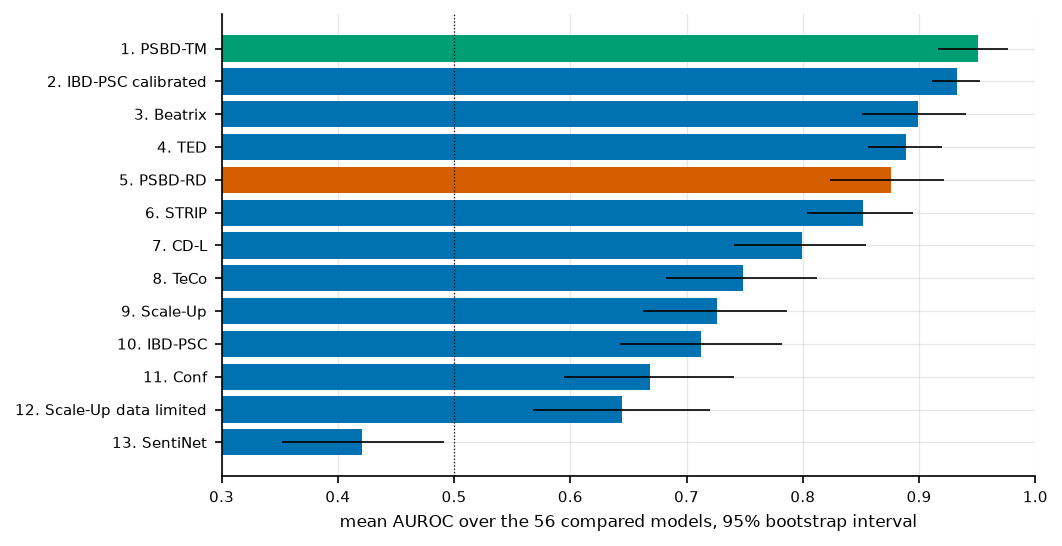

PSBD-TM rank 1 of 13, PSBD-RD rank 5
strongest competitor IBD-PSC calibrated, paired margin +0.018 [-0.017, +0.048]


In [5]:
means = per_model[defense_names].mean().sort_values(ascending=False)  # (defenses,)
intervals = {name: bootstrap_ci(per_model[name].tolist(), BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED) for name in means.index}

figure, axis = plt.subplots(figsize=(7.0, 4.0))
colors = ["#009E73" if n == "PSBD-TM" else "#D55E00" if n == "PSBD-RD" else "#0072B2" for n in means.index]
axis.barh(range(len(means)), means.values, color=colors)
axis.errorbar(means.values, range(len(means)), xerr=np.array([[m - intervals[n][0], intervals[n][1] - m] for n, m in means.items()]).T, fmt="none", ecolor="black", lw=0.8)
axis.set_yticks(range(len(means)), labels=[f"{rank}. {name}" for rank, name in enumerate(means.index, start=1)])
axis.invert_yaxis()
axis.axvline(0.5, color="black", lw=0.6, ls=":")
axis.set_xlim(0.3, 1.0)
axis.set_xlabel(f"mean AUROC over the {len(per_model)} compared models, 95% bootstrap interval")
plt.show()

best_competitor = [n for n in means.index if not n.startswith("PSBD")][0]
margin = per_model["PSBD-TM"] - per_model[best_competitor]  # (models,)
# The bootstrap resamples in the order the generator reads the models, grouped by
# dataset in build_rows, so the interval is taken over that order to match it.
_rows, _overall, _dataset_means, generator_readings = build_rows("results", compared, HEADLINE_KEY, "auroc")
generator_margin = [r["PSBD-TM"] - r[best_competitor.replace(" calibrated", "$^\\ast$")] for r in generator_readings]
margin_low, margin_high = bootstrap_ci(generator_margin, BOOTSTRAP_RESAMPLES, BOOTSTRAP_SEED)
assert fmt(means["PSBD-TM"]) == macro("detectors", "DetectorsAurocOurs")
assert fmt(means[best_competitor]) == macro("detectors", "DetectorsAurocBestCompetitor")
assert fmt(margin.mean(), signed=True) == macro("detectors", "DetectorsAurocMargin")
assert fmt(margin_low, signed=True) == macro("detectors", "DetectorsAurocMarginLow")
print(f"PSBD-TM rank {list(means.index).index('PSBD-TM') + 1} of {len(means)}, PSBD-RD rank {list(means.index).index('PSBD-RD') + 1}")
print(f"strongest competitor {best_competitor}, paired margin {margin.mean():+.3f} [{margin_low:+.3f}, {margin_high:+.3f}]")
rank_of = {name: rank for rank, name in enumerate(means.index, start=1)}
ahead_of_published = [n for n in means.index[: rank_of["PSBD-RD"] - 1] if n != "PSBD-TM"]
published_neighbors = [n for n in means.index[rank_of["PSBD-RD"]:] if abs(means[n] - means["PSBD-RD"]) < 0.005]

In [6]:
display(Markdown(rf"""
PSBD-TM ranks {ordinal(rank_of["PSBD-TM"])} of {len(means)} at {means["PSBD-TM"]:.3f} and the strongest competitor is {best_competitor} at {means[best_competitor]:.3f}, a paired margin of {margin.mean():+.3f} [{margin_low:+.3f}, {margin_high:+.3f}] (`\DetectorsAurocMargin`). PSBD-RD ranks {ordinal(rank_of["PSBD-RD"])} (`\DetectorsAurocRankPublished`), behind {word_list(ahead_of_published)}{f" and level with {word_list(published_neighbors)}" if published_neighbors else ""}. The faithful IBD-PSC port at the paper's fixed factor {macro("detectors", "DetectorsIbdPscFactor")} reads {means["IBD-PSC"]:.3f}, far below its calibrated variant. SentiNet reads {means["SentiNet"]:.3f}, {"below" if means["SentiNet"] < 0.5 else "above"} chance, since its Grad-CAM mask misses the trigger on a ViT. The per-mean intervals overlap for the top 3, and only the paired margin separates them. The figure does not show where each defense wins, which the per-attack heatmap does.
"""))


PSBD-TM ranks 1st of 13 at 0.951 and the strongest competitor is IBD-PSC calibrated at 0.933, a paired margin of +0.018 [-0.017, +0.048] (`\DetectorsAurocMargin`). PSBD-RD ranks 5th (`\DetectorsAurocRankPublished`), behind IBD-PSC calibrated, Beatrix and TED. The faithful IBD-PSC port at the paper's fixed factor 1.5 reads 0.713, far below its calibrated variant. SentiNet reads 0.421, below chance, since its Grad-CAM mask misses the trigger on a ViT. The per-mean intervals overlap for the top 3, and only the paired margin separates them. The figure does not show where each defense wins, which the per-attack heatmap does.


## AUROC per attack

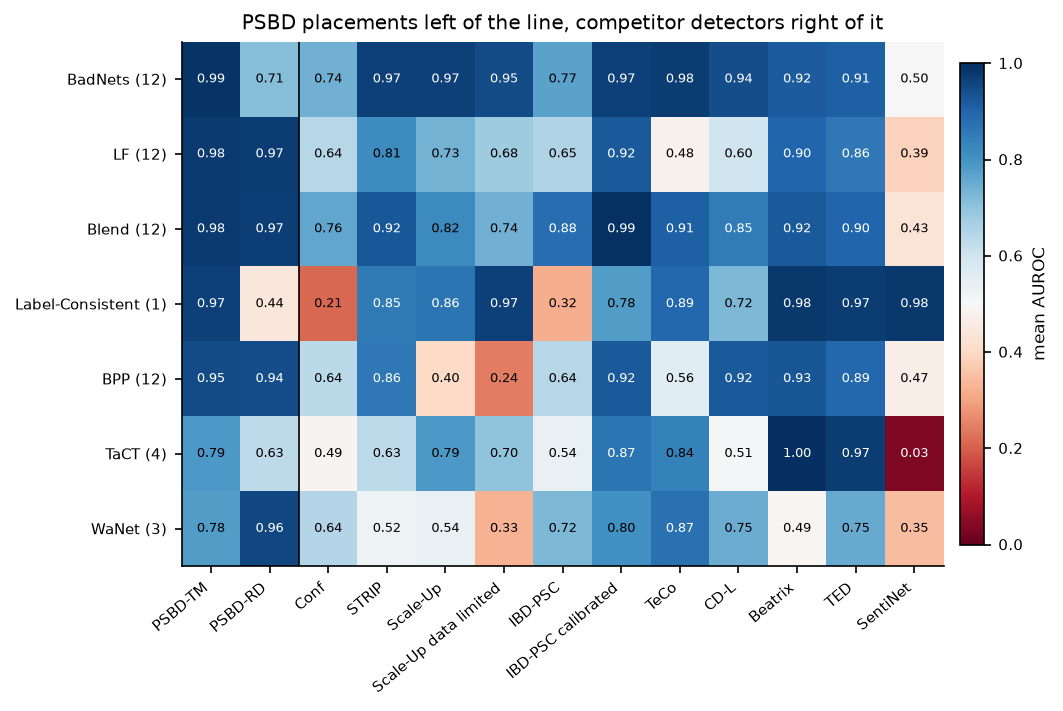

,PSBD-TM,PSBD-RD,Conf,STRIP,Scale-Up,Scale-Up data limited,IBD-PSC,IBD-PSC calibrated,TeCo,CD-L,Beatrix,TED,SentiNet
attack,,,,,,,,,,,,,
BadNets,0.992,0.712,0.742,0.968,0.968,0.949,0.768,0.967,0.976,0.943,0.916,0.909,0.499
LF,0.980,0.974,0.642,0.813,0.734,0.677,0.649,0.919,0.477,0.599,0.897,0.858,0.387
Blend,0.978,0.971,0.758,0.922,0.819,0.741,0.881,0.993,0.907,0.850,0.920,0.896,0.431
Label-Consistent,0.969,0.444,0.211,0.854,0.864,0.967,0.318,0.778,0.894,0.723,0.984,0.975,0.982
BPP,0.948,0.945,0.637,0.859,0.399,0.243,0.642,0.920,0.562,0.921,0.926,0.891,0.469
TaCT,0.788,0.630,0.485,0.631,0.785,0.700,0.536,0.867,0.838,0.506,0.999,0.973,0.032
WaNet,0.779,0.955,0.645,0.525,0.539,0.327,0.724,0.804,0.871,0.746,0.490,0.753,0.347


In [7]:
per_attack = per_model.groupby("attack")[defense_names].mean()  # (attacks, defenses)
models_per_attack = per_model.groupby("attack").size()
per_attack = per_attack.sort_values("PSBD-TM", ascending=False)
assert per_attack.shape == (per_model["attack"].nunique(), len(defense_names))


def plot_heatmap(grid, row_counts, title, label):
    values = grid.to_numpy()  # (rows, defenses)
    figure, axis = plt.subplots(figsize=(TEXT_WIDTH, 0.42 * len(grid) + 1.6))
    # Chance sits at the middle of the color scale, so a defense that orders poisoned
    # and clean inputs the wrong way round reads red rather than as a pale blue.
    color_norm = TwoSlopeNorm(vmin=0.0, vcenter=0.5, vmax=1.0)
    image = axis.imshow(values, cmap="RdBu", norm=color_norm, aspect="auto")
    for row_index in range(values.shape[0]):
        for column_index in range(values.shape[1]):
            value = values[row_index, column_index]
            axis.text(column_index, row_index, f"{value:.2f}", ha="center", va="center", fontsize=6,
                      color="white" if abs(value - 0.5) > 0.35 else "black")
    axis.set_xticks(range(len(grid.columns)), labels=grid.columns, rotation=40, ha="right")
    axis.set_yticks(range(len(grid)), labels=[f"{name} ({row_counts[name]})" for name in grid.index])
    axis.grid(False)
    axis.axvline(1.5, color="black", linewidth=0.8)
    figure.colorbar(image, ax=axis, label=label, fraction=0.03, pad=0.02)
    axis.set_title(title)
    plt.show()


plot_heatmap(per_attack, models_per_attack, "PSBD placements left of the line, competitor detectors right of it", "mean AUROC")
per_attack.round(3)

## Leaders per attack

The table reads the heatmap row by row: which defense has the highest mean on each attack and where the 2 PSBD placements rank among all of them.

In [8]:
ranks = per_attack.rank(axis=1, ascending=False, method="min")  # (attacks, defenses)
leaders = pd.DataFrame(
    {
        "models": models_per_attack.loc[per_attack.index],
        "PSBD-TM": per_attack["PSBD-TM"].round(3),
        "PSBD-TM rank": ranks["PSBD-TM"].astype(int),
        "PSBD-RD": per_attack["PSBD-RD"].round(3),
        "PSBD-RD rank": ranks["PSBD-RD"].astype(int),
        "leader": per_attack.idxmax(axis=1),
        "leader AUROC": per_attack.max(axis=1).round(3),
    }
)
tm_leads = (ranks["PSBD-TM"] == 1).sum()
tm_beats_rd = (per_attack["PSBD-TM"] > per_attack["PSBD-RD"]).sum()
print(f"PSBD-TM leads {tm_leads} of {len(per_attack)} attacks")
print(f"PSBD-TM beats PSBD-RD on {tm_beats_rd} of {len(per_attack)} attacks")
tm_leads_on = list(per_attack.index[ranks["PSBD-TM"] == 1])
tm_other_ranks = {a: int(ranks.loc[a, "PSBD-TM"]) for a in per_attack.index if ranks.loc[a, "PSBD-TM"] > 1}
gain_over_rd = (per_attack["PSBD-TM"] - per_attack["PSBD-RD"]).sort_values(ascending=False)
sentinet_max = per_attack["SentiNet"].max()
leaders

PSBD-TM leads 3 of 7 attacks
PSBD-TM beats PSBD-RD on 6 of 7 attacks


,models,PSBD-TM,PSBD-TM rank,PSBD-RD,PSBD-RD rank,leader,leader AUROC
attack,,,,,,,
BadNets,12,0.992,1,0.712,12,PSBD-TM,0.992
LF,12,0.980,1,0.974,2,PSBD-TM,0.980
Blend,12,0.978,2,0.971,3,IBD-PSC calibrated,0.993
Label-Consistent,1,0.969,4,0.444,11,Beatrix,0.984
BPP,12,0.948,1,0.945,2,PSBD-TM,0.948
TaCT,4,0.788,5,0.630,9,Beatrix,0.999
WaNet,3,0.779,4,0.955,1,PSBD-RD,0.955


In [9]:
display(Markdown(rf"""
No single defense leads every row. PSBD-TM leads {word_list(tm_leads_on)} and ranks {word_list([f"{ordinal(r)} on {a}" for a, r in tm_other_ranks.items()])}. Its largest gains over PSBD-RD are on {word_list(list(gain_over_rd.index[:2]))}, where PSBD-RD reads {word_list([f"{per_attack.loc[a, 'PSBD-RD']:.3f}" for a in gain_over_rd.index[:2]])}. The row leaders are {word_list([f"{leaders.loc[a, 'leader']} on {a}" for a in per_attack.index])}. SentiNet reads at most {sentinet_max:.3f} on any attack. Each row is a mean over models of different datasets and poison rates, and the models per attack are uneven ({word_list([f"{n} for {a}" for a, n in models_per_attack.sort_values(ascending=False).items()])}), so a row compares defenses with each other and says little about how hard 1 attack is against another. The overall means weigh every model equally rather than every attack, which is why they put PSBD-TM first while this breakdown shows where others win.
"""))


No single defense leads every row. PSBD-TM leads BadNets, LF and BPP and ranks 2nd on Blend, 4th on Label-Consistent, 5th on TaCT and 4th on WaNet. Its largest gains over PSBD-RD are on Label-Consistent and BadNets, where PSBD-RD reads 0.444 and 0.712. The row leaders are PSBD-TM on BadNets, PSBD-TM on LF, IBD-PSC calibrated on Blend, Beatrix on Label-Consistent, PSBD-TM on BPP, Beatrix on TaCT and PSBD-RD on WaNet. SentiNet reads at most 0.982 on any attack. Each row is a mean over models of different datasets and poison rates, and the models per attack are uneven (12 for BPP, 12 for BadNets, 12 for Blend, 12 for LF, 4 for TaCT, 3 for WaNet and 1 for Label-Consistent), so a row compares defenses with each other and says little about how hard 1 attack is against another. The overall means weigh every model equally rather than every attack, which is why they put PSBD-TM first while this breakdown shows where others win.


## The low false-positive budget

AUROC averages over every threshold. A deployed detector runs at 1 threshold, and the paper's second metric is the TPR at the `q0.10` clean-validation quantile, the share of triggered images flagged when about that share of clean images are. The heatmap repeats the per-attack view for that TPR.

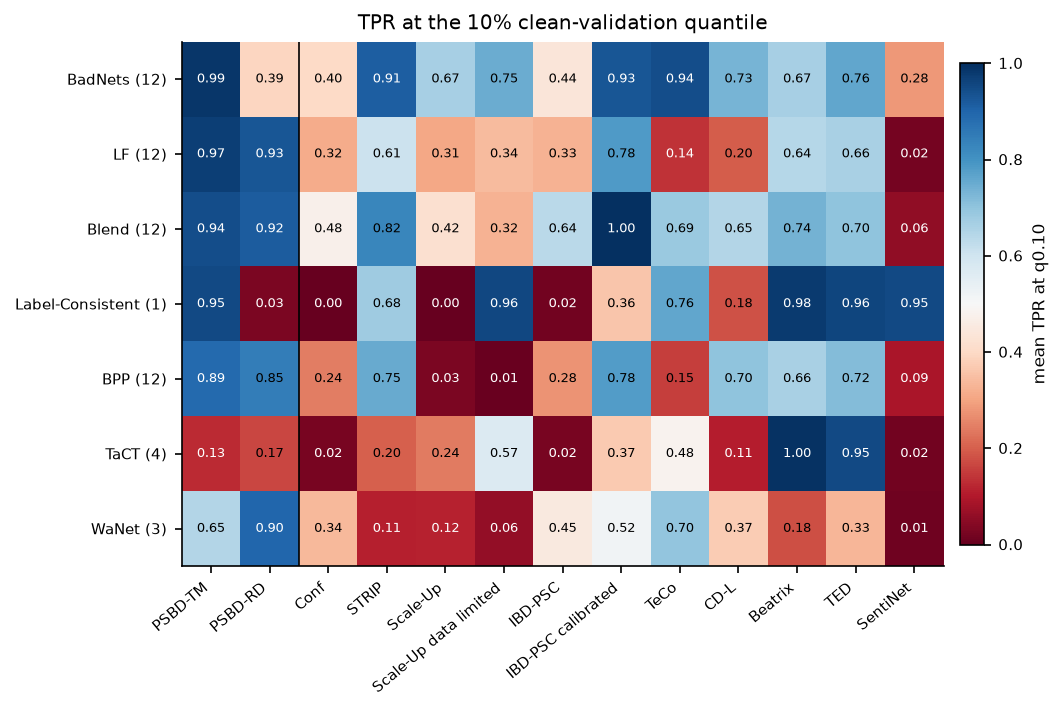

mean TPR at q0.10: PSBD-TM 0.872, rank 1 of 13, best competitor IBD-PSC calibrated


In [10]:
tpr_per_attack = per_model_tpr.groupby("attack")[defense_names].mean().reindex(per_attack.index)  # (attacks, defenses)
plot_heatmap(tpr_per_attack, models_per_attack, "TPR at the 10% clean-validation quantile", "mean TPR at q0.10")
tpr_means = per_model_tpr[defense_names].mean().sort_values(ascending=False)
assert fmt(tpr_means["PSBD-TM"]) == macro("detectors", "DetectorsTprOneZeroOurs")
print(f"mean TPR at q0.10: PSBD-TM {tpr_means['PSBD-TM']:.3f}, rank {list(tpr_means.index).index('PSBD-TM') + 1} of {len(tpr_means)}, "
      f"best competitor {[n for n in tpr_means.index if not n.startswith('PSBD')][0]}")
tpr_margin = per_model_tpr["PSBD-TM"] - per_model_tpr[best_competitor]  # (models,)
tpr_rank_published = list(tpr_means.index).index("PSBD-RD") + 1
collapsed = [n for n in defense_names if not n.startswith("PSBD") and tpr_means[n] < 0.5]

In [11]:
display(Markdown(rf"""
At this budget PSBD-TM flags {tpr_means["PSBD-TM"]:.3f} of triggered images on average, {ordinal(list(tpr_means.index).index("PSBD-TM") + 1)} of {len(tpr_means)} (`\DetectorsTprOneZeroOurs`). Its margin over {best_competitor} is {tpr_margin.mean():+.3f} (`\DetectorsTprOneZeroMargin`, interval {macro("detectors", "DetectorsTprOneZeroMarginLow")} to {macro("detectors", "DetectorsTprOneZeroMarginHigh")}), against {margin.mean():+.3f} on AUROC. PSBD-RD ranks {ordinal(tpr_rank_published)}. {len(collapsed)} competitors flag fewer than half the triggered images at this budget ({word_list(collapsed)}), because a high AUROC can come from ranking well in the middle of the distributions while missing the tail a threshold cuts. The color scale still centers on 0.5, which for a TPR is not a chance line, so the red cells here mean low detection rather than inversion.
"""))


At this budget PSBD-TM flags 0.872 of triggered images on average, 1st of 13 (`\DetectorsTprOneZeroOurs`). Its margin over IBD-PSC calibrated is +0.064 (`\DetectorsTprOneZeroMargin`, interval +0.006 to +0.125), against +0.018 on AUROC. PSBD-RD ranks 3rd. 6 competitors flag fewer than half the triggered images at this budget (Conf, Scale-Up, Scale-Up data limited, IBD-PSC, TeCo and SentiNet), because a high AUROC can come from ranking well in the middle of the distributions while missing the tail a threshold cuts. The color scale still centers on 0.5, which for a TPR is not a chance line, so the red cells here mean low detection rather than inversion.


## AUROC per dataset

The same comparison per dataset asks whether a defense's rank depends on the image domain, since the 4 datasets differ in resolution, class count and content.

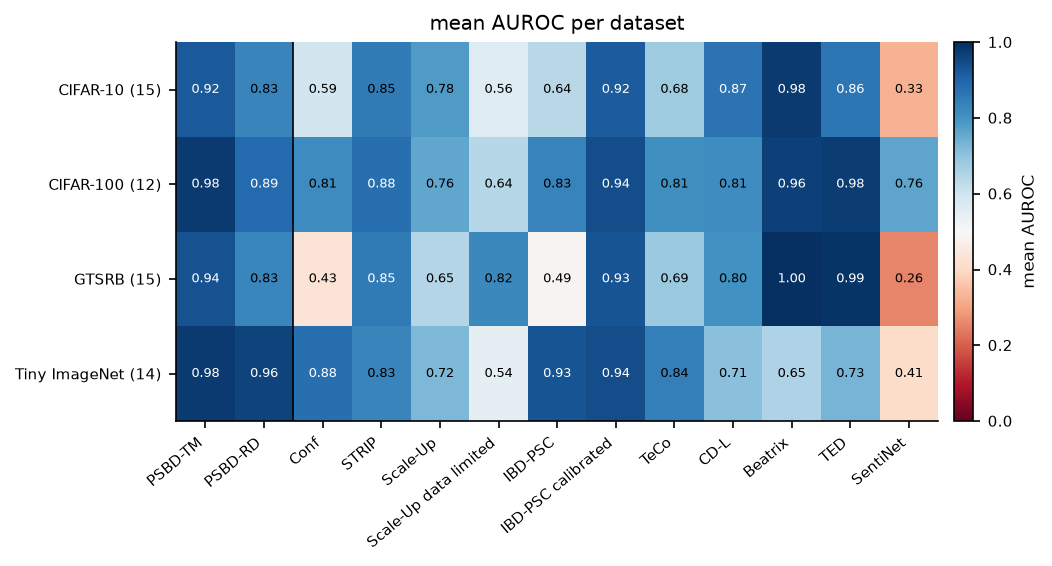

dataset leaders: {'CIFAR-10': 'Beatrix', 'CIFAR-100': 'PSBD-TM', 'GTSRB': 'Beatrix', 'Tiny ImageNet': 'PSBD-TM'}
macros: CIFAR-100 and Tiny ImageNet | Beatrix on CIFAR-10 and GTSRB


In [12]:
per_dataset = per_model.groupby("dataset")[defense_names].mean()  # (datasets, defenses)
models_per_dataset = per_model.groupby("dataset").size()
plot_heatmap(per_dataset, models_per_dataset, "mean AUROC per dataset", "mean AUROC")
print("dataset leaders:", per_dataset.idxmax(axis=1).to_dict())
print("macros:", macro("detectors", "DetectorsAurocDatasetsOursLeads"), "|", macro("detectors", "DetectorsAurocDatasetsOthersLead"))
dataset_leaders = per_dataset.idxmax(axis=1)
tm_leads_datasets = list(dataset_leaders.index[dataset_leaders == "PSBD-TM"])
others_lead = {d: l for d, l in dataset_leaders.items() if l != "PSBD-TM"}
tm_weakest_dataset = per_dataset["PSBD-TM"].idxmin()

In [13]:
display(Markdown(rf"""
PSBD-TM has the highest mean on {word_list(tm_leads_datasets)}, and {word_list([f"{l} leads {d}" for d, l in others_lead.items()])} (`\DetectorsAurocDatasetsOursLeads`, `\DetectorsAurocDatasetsOthersLead`). PSBD-TM is weakest on {tm_weakest_dataset} ({per_dataset.loc[tm_weakest_dataset, "PSBD-TM"]:.3f}), and Beatrix ranges from {per_dataset["Beatrix"].min():.3f} on {per_dataset["Beatrix"].idxmin()} to {per_dataset["Beatrix"].max():.3f} on {per_dataset["Beatrix"].idxmax()}. The dataset split mixes attacks in different proportions per dataset (CIFAR-10 holds {int(((per_model["dataset"] == "CIFAR-10") & (per_model["attack"] == "SIG")).sum())} of the {int((per_model["attack"] == "SIG").sum())} SIG models and {int(((per_model["dataset"] == "CIFAR-10") & (per_model["attack"] == "WaNet")).sum())} of the {int((per_model["attack"] == "WaNet").sum())} WaNet models), so a dataset row is partly an attack row in disguise.
"""))


PSBD-TM has the highest mean on CIFAR-100 and Tiny ImageNet, and Beatrix leads CIFAR-10 and Beatrix leads GTSRB (`\DetectorsAurocDatasetsOursLeads`, `\DetectorsAurocDatasetsOthersLead`). PSBD-TM is weakest on CIFAR-10 (0.919), and Beatrix ranges from 0.655 on Tiny ImageNet to 0.998 on GTSRB. The dataset split mixes attacks in different proportions per dataset (CIFAR-10 holds 0 of the 0 SIG models and 1 of the 3 WaNet models), so a dataset row is partly an attack row in disguise.


## PSBD-TM against the strongest competitor, model by model

A mean margin can come from a small edge everywhere or a large edge on a few models. The scatter places every model by its PSBD-TM and calibrated IBD-PSC AUROC.

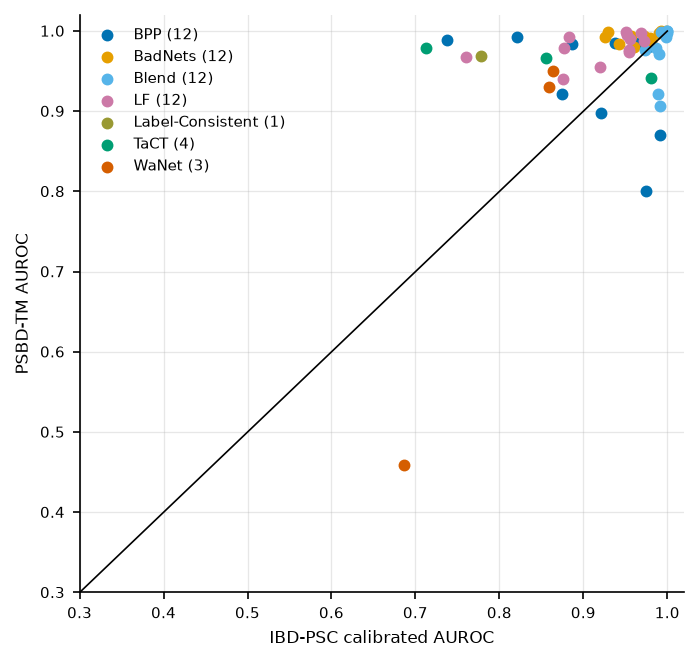

PSBD-TM ahead on 43 of 56 models, behind on 13


In [14]:
figure, axis = plt.subplots(figsize=(5.2, 5.0))
attack_tokens = {attack_label(c["attack"]): c["attack"] for c in compared}
for attack, rows in per_model.groupby("attack"):
    axis.scatter(rows[best_competitor], rows["PSBD-TM"], s=22, color=attack_color(attack_tokens[attack]), label=f"{attack} ({len(rows)})")
axis.plot([0, 1], [0, 1], color="black", lw=0.8)
axis.set_xlim(0.3, 1.02)
axis.set_ylim(0.3, 1.02)
axis.set_xlabel(f"{best_competitor} AUROC")
axis.set_ylabel("PSBD-TM AUROC")
axis.legend()
plt.show()
print(f"PSBD-TM ahead on {(margin > 0).sum()} of {len(margin)} models, behind on {(margin < 0).sum()}")
scatter = per_model.assign(margin=margin)
clear_wins = scatter[scatter["margin"] > 0.05]
clear_losses = scatter[scatter["margin"] < -0.05]

In [15]:
display(Markdown(rf"""
Most models sit near the top right, where both detectors are above 0.9 and the margin is small, and PSBD-TM is ahead on {int((margin > 0).sum())} of the {len(margin)}. It leads by more than 0.05 on {len(clear_wins)} models ({word_list(sorted(set(clear_wins["attack"])))}), where {best_competitor} reads between {clear_wins[best_competitor].min():.2f} and {clear_wins[best_competitor].max():.2f}, and trails by more than 0.05 on {len(clear_losses)} ({word_list(sorted(set(clear_losses["attack"])))}), where PSBD-TM reads between {clear_losses["PSBD-TM"].min():.2f} and {clear_losses["PSBD-TM"].max():.2f}. The paired interval on the margin {"excludes" if margin_low > 0 else "includes"} 0 at the headline quantile, and the per-model picture shows a tie on most models and a clear difference on a few. The figure does not show the TPR margin or the cost of the 2 detectors, which differs: IBD-PSC needs 1 amplified pass per candidate depth, PSBD-TM 1 perturbed pass per $k$.
"""))


Most models sit near the top right, where both detectors are above 0.9 and the margin is small, and PSBD-TM is ahead on 43 of the 56. It leads by more than 0.05 on 14 models (BPP, BadNets, LF, Label-Consistent, TaCT and WaNet), where IBD-PSC calibrated reads between 0.71 and 0.93, and trails by more than 0.05 on 6 (BPP, Blend, TaCT and WaNet), where PSBD-TM reads between 0.27 and 0.92. The paired interval on the margin includes 0 at the headline quantile, and the per-model picture shows a tie on most models and a clear difference on a few. The figure does not show the TPR margin or the cost of the 2 detectors, which differs: IBD-PSC needs 1 amplified pass per candidate depth, PSBD-TM 1 perturbed pass per $k$.
